# 📊 Cognitive-Logix — Tüm Analiz ve Model Grafikleri (Grafik 1–12)

Bu notebook, **temiz_veri_final_latest.csv** verisi üzerinde 12 adet analiz ve model grafiği üretmektedir.

### 🟠 Bölüm A — Veri Analizi Grafikleri
| # | Grafik Adı | Tür |
|---|-----------|-----|
| 1 | Öznitelik Korelasyon Isı Haritası | Correlation Heatmap |
| 2 | Aylık Satış Trendi — Kategorilere Göre | Çizgi Grafiği |
| 3 | Haversine Mesafesi Dağılımı | Histogram |
| 4 | Fraud vs Normal Sipariş — Z-Skoru Kutu Grafiği | Box Plot |

### 🟢 Bölüm B — Model ve Analiz Grafikleri
| # | Grafik Adı | Tür |
|---|-----------|-----|
| 5 | Outlier Dağılımı — Fraud vs Normal | Box Plot |
| 6 | Normalizasyon Öncesi/Sonrası Dağılımlar | Before/After Histogram |
| 7 | Karar Ağacı Görselleştirmesi (max_depth=5) | Decision Tree |
| 8 | Sınıflandırma Sonuçları — Confusion Matrix | Heatmap |

### 🔵 Bölüm C — Model Çıktısı Grafikleri
| # | Grafik Adı | Tür |
|---|-----------|-----|
| 9 | SHAP Summary Plot — Öznitelik Önem Sıralaması | SHAP |
| 10 | ROC-AUC Eğrisi — Decision Tree vs XGBoost | ROC Curve |
| 11 | Prophet 12 Aylık Talep Tahmini | Trend & Mevsimsellik |
| 12 | Isolation Forest — Anomali Skoru Dağılımı | Histogram |

In [1]:
# ============================================================
# KÜTÜPHANELER
# ============================================================
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.ensemble import IsolationForest

import xgboost as xgb
import shap
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')

# Stil ayarları
sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['figure.dpi'] = 120

import os
os.makedirs('../../analysis_images', exist_ok=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')

✅ Tüm kütüphaneler başarıyla yüklendi.


C:\Users\Win11\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# VERİ YÜKLEME
# ============================================================
df = pd.read_csv('../../data/temiz_veri_final_latest.csv')

# Fraud etiketi oluştur (string label — seaborn uyumluluğu için)
df['fraud_label'] = df['Order Status'].apply(
    lambda x: 'Fraud' if x == 'SUSPECTED_FRAUD' else 'Normal'
)
df['is_fraud'] = (df['Order Status'] == 'SUSPECTED_FRAUD').astype(int)

# Tarih sütunu
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

print(f'📋 Veri boyutu: {df.shape[0]:,} satır × {df.shape[1]} sütun')
print(f'\n🔍 Fraud dağılımı:')
print(df['fraud_label'].value_counts())

📋 Veri boyutu: 180,519 satır × 57 sütun

🔍 Fraud dağılımı:
fraud_label
Normal    176457
Fraud       4062
Name: count, dtype: int64


---
# 🟠 BÖLÜM A — VERİ ANALİZİ GRAFİKLERİ

## 📌 [Grafik 1] Öznitelik Korelasyon Isı Haritası (Correlation Heatmap)

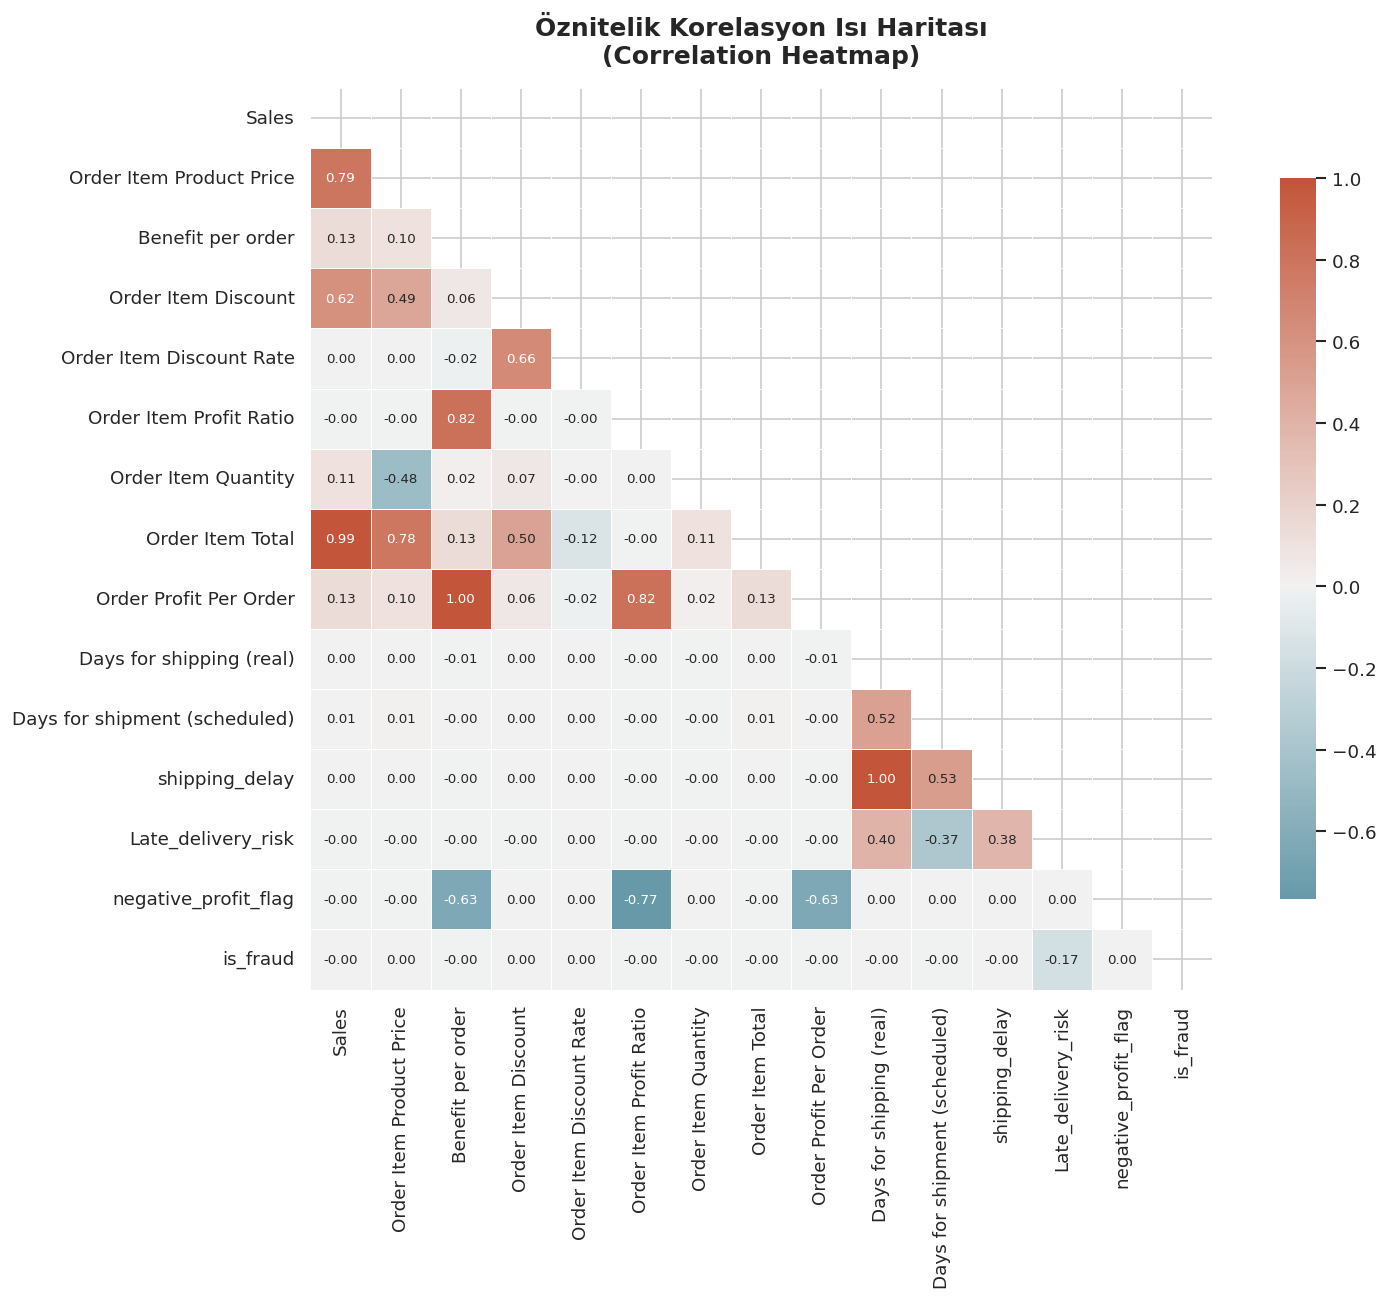

✅ Grafik 1 kaydedildi.


In [3]:
# ============================================================
# GRAFİK 1: Öznitelik Korelasyon Isı Haritası
# ============================================================
selected_cols = [
    'Sales', 'Order Item Product Price', 'Benefit per order',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Profit Ratio', 'Order Item Quantity',
    'Order Item Total', 'Order Profit Per Order',
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'shipping_delay', 'Late_delivery_risk',
    'negative_profit_flag', 'is_fraud'
]

corr = df[selected_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    square=True, ax=ax, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Öznitelik Korelasyon Isı Haritası\n(Correlation Heatmap)',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik01_korelasyon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 1 kaydedildi.')

## 📌 [Grafik 2] Aylık Satış Trendi — Kategorilere Göre Çizgi Grafiği

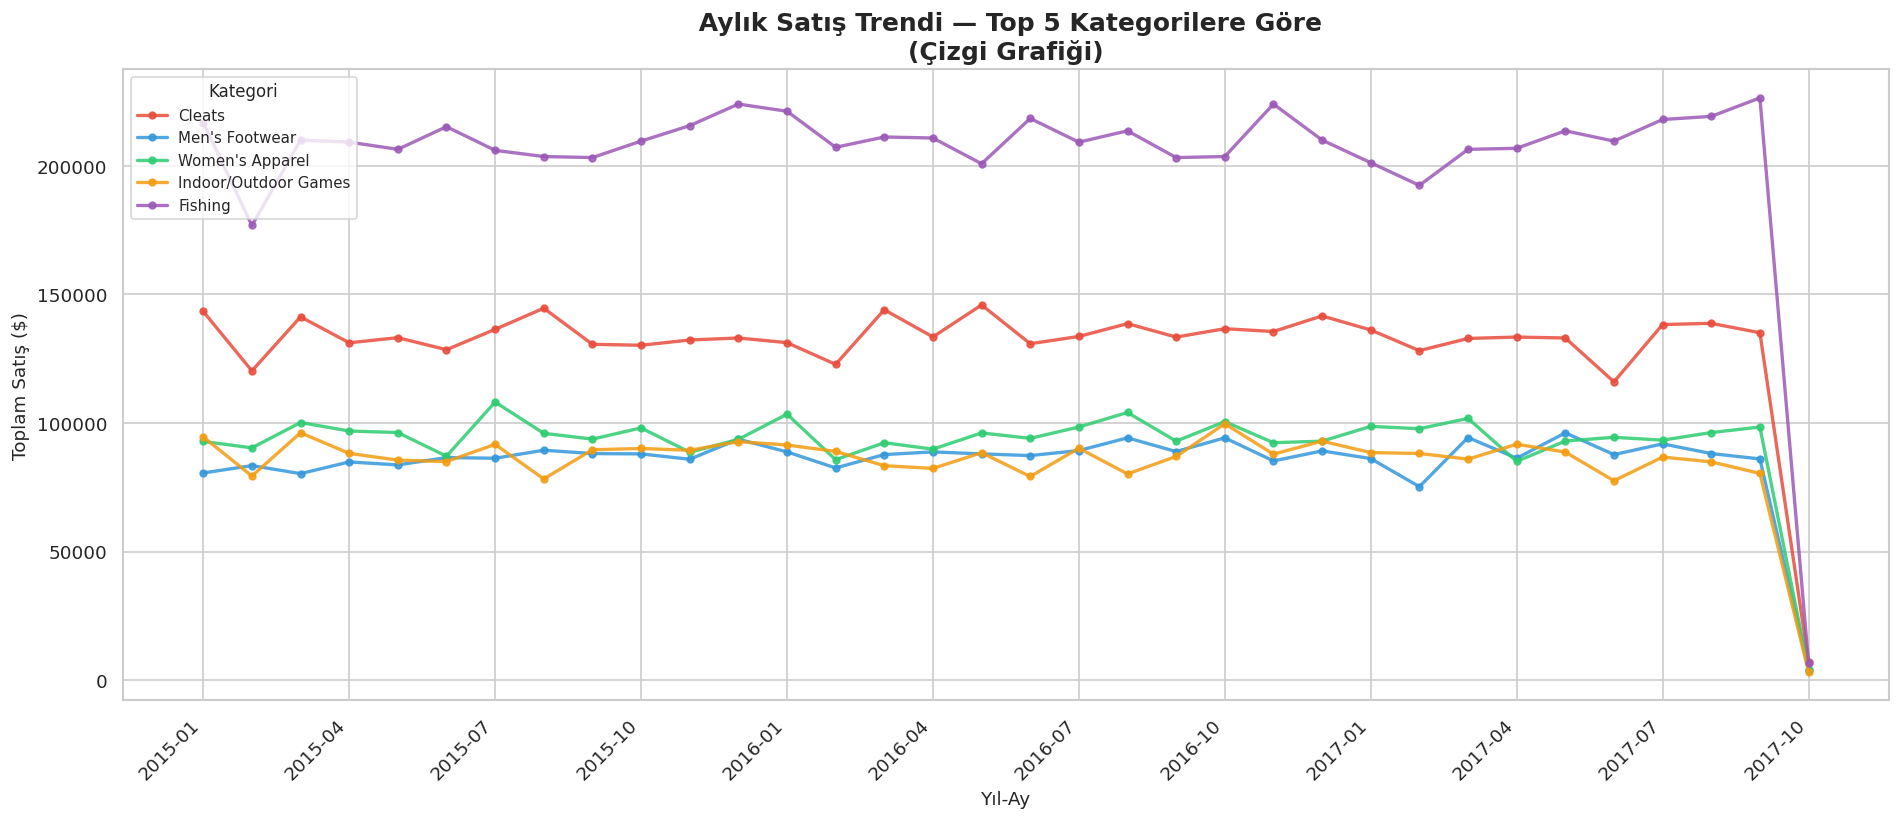

✅ Grafik 2 kaydedildi.


In [4]:
# ============================================================
# GRAFİK 2: Aylık Satış Trendi — Kategorilere Göre
# ============================================================
top5_cats = df['Category Name'].value_counts().head(5).index.tolist()
df_top5 = df[df['Category Name'].isin(top5_cats)].copy()
df_top5['year_month'] = df_top5['order_date'].dt.to_period('M')

monthly_sales = (df_top5.groupby(['year_month', 'Category Name'])['Sales']
                 .sum().reset_index())
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i, cat in enumerate(top5_cats):
    cat_data = monthly_sales[monthly_sales['Category Name'] == cat]
    ax.plot(cat_data['year_month'], cat_data['Sales'],
            marker='o', markersize=4, linewidth=2,
            color=colors[i], label=cat, alpha=0.85)

ax.set_title(' Aylık Satış Trendi — Top 5 Kategorilere Göre\n(Çizgi Grafiği)',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Yıl-Ay', fontsize=11)
ax.set_ylabel('Toplam Satış ($)', fontsize=11)
ax.legend(title='Kategori', fontsize=9, title_fontsize=10, loc='upper left')

# Her 3. tick'i göster
xticks = ax.get_xticks()
ax.set_xticks(xticks[::max(1, len(xticks)//10)])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../../analysis_images/grafik02_aylik_satis_trendi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 2 kaydedildi.')

## 📌 [Grafik 3] Haversine Mesafesi Dağılımı (Histogram)

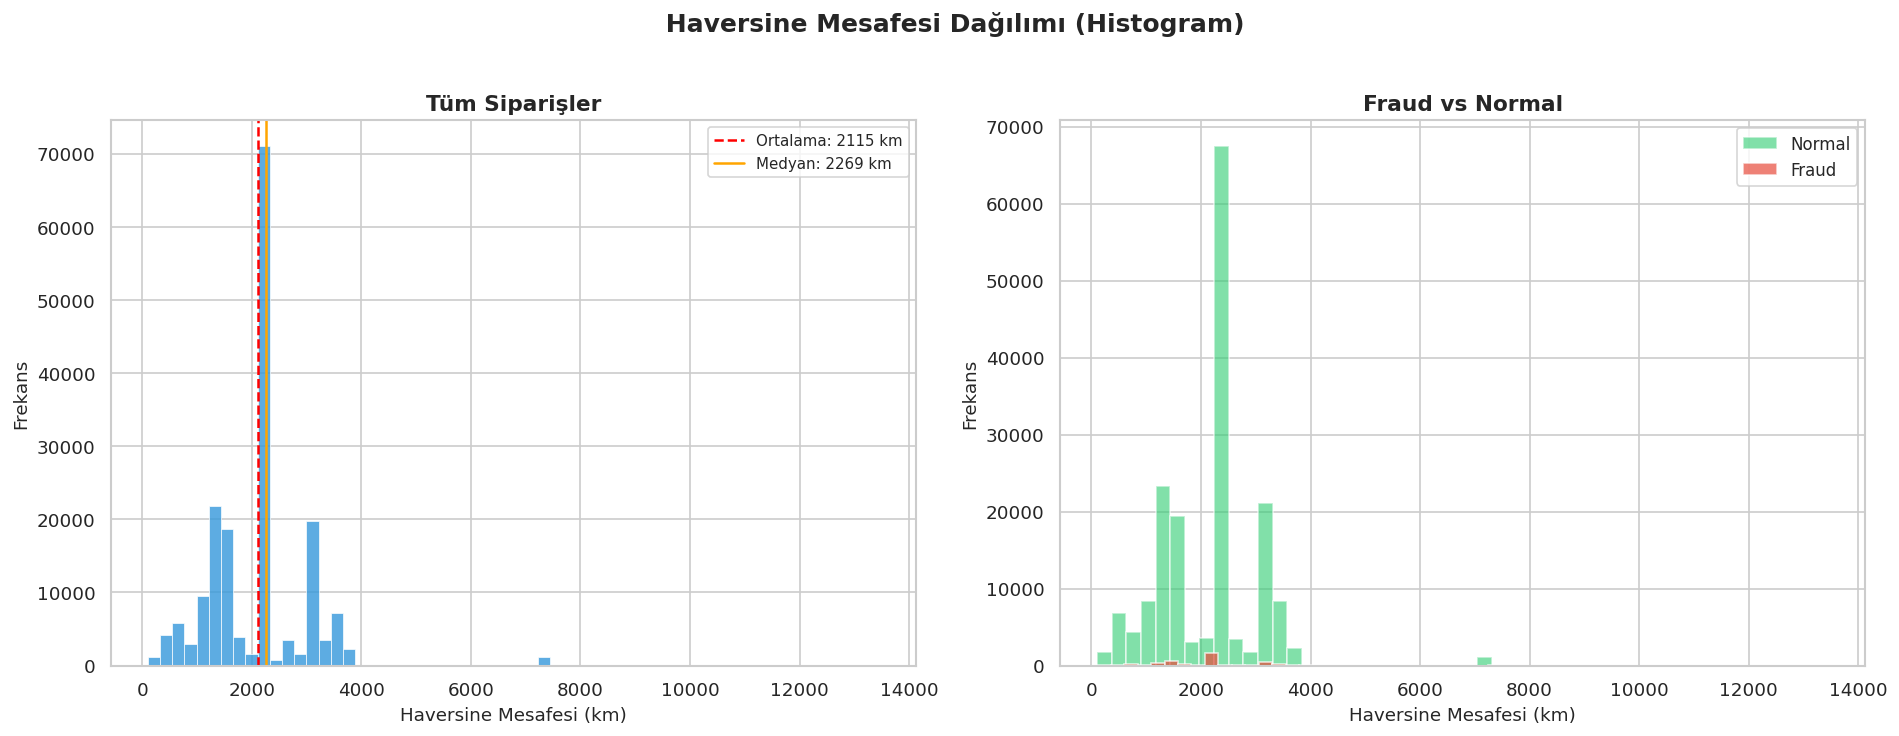

✅ Grafik 3 kaydedildi.


In [5]:
# ============================================================
# GRAFİK 3: Haversine Mesafesi Dağılımı
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    """İki koordinat arasındaki Haversine mesafesini km cinsinden hesaplar."""
    R = 6371  # Dünya yarıçapı (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()

df['haversine_km'] = haversine(
    df['Latitude'], df['Longitude'],
    center_lat, center_lon
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Genel dağılım
axes[0].hist(df['haversine_km'], bins=60, color='#3498db', alpha=0.8,
             edgecolor='white', linewidth=0.5)
axes[0].axvline(df['haversine_km'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Ortalama: {df["haversine_km"].mean():.0f} km')
axes[0].axvline(df['haversine_km'].median(), color='orange', linestyle='-', linewidth=1.5,
                label=f'Medyan: {df["haversine_km"].median():.0f} km')
axes[0].set_title('Tüm Siparişler', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Haversine Mesafesi (km)', fontsize=11)
axes[0].set_ylabel('Frekans', fontsize=11)
axes[0].legend(fontsize=9)

# Sağ: Fraud vs Normal karşılaştırması
axes[1].hist(df[df['is_fraud']==0]['haversine_km'], bins=50, alpha=0.6,
             color='#2ecc71', label='Normal', edgecolor='white')
axes[1].hist(df[df['is_fraud']==1]['haversine_km'], bins=50, alpha=0.7,
             color='#e74c3c', label='Fraud', edgecolor='white')
axes[1].set_title('Fraud vs Normal', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Haversine Mesafesi (km)', fontsize=11)
axes[1].set_ylabel('Frekans', fontsize=11)
axes[1].legend(fontsize=10)

fig.suptitle(' Haversine Mesafesi Dağılımı (Histogram)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik03_haversine_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 3 kaydedildi.')

## 📌 [Grafik 4] Fraud vs Normal Sipariş — Z-Skoru Kutu Grafiği (Box Plot)

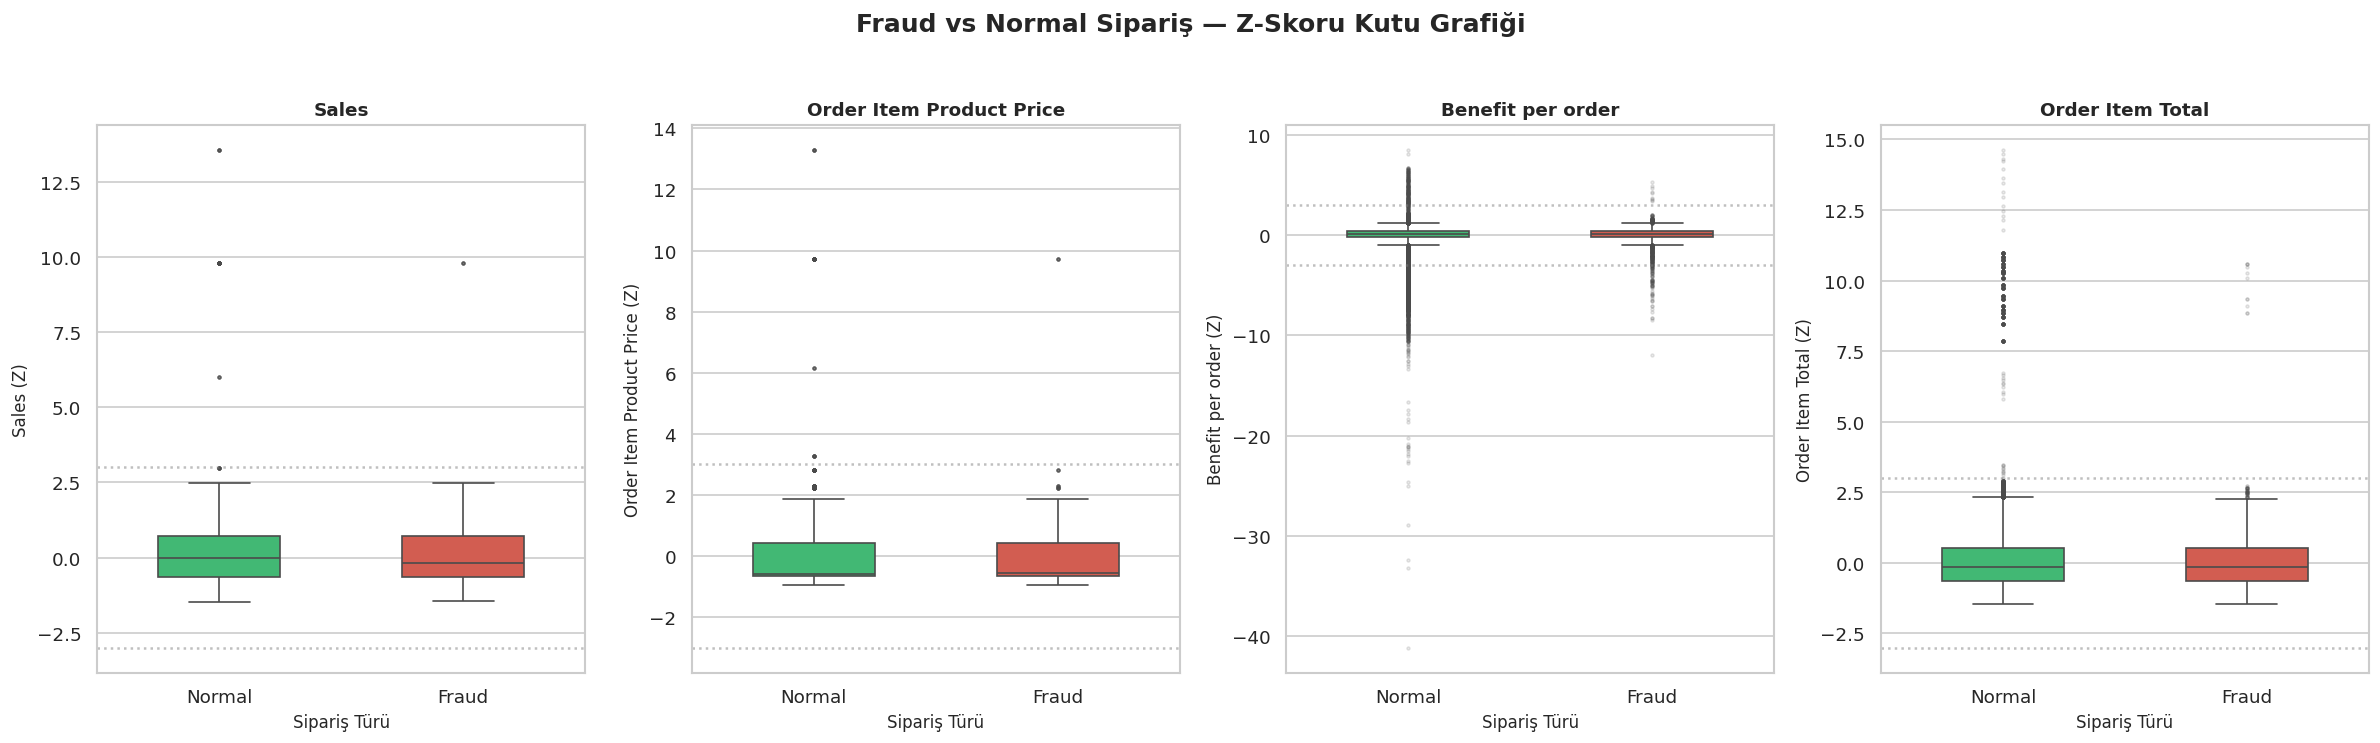

✅ Grafik 4 kaydedildi.


In [6]:
# ============================================================
# GRAFİK 4: Fraud vs Normal Sipariş — Z-Skoru Box Plot
# ============================================================
zscore_cols = ['Sales', 'Order Item Product Price', 'Benefit per order', 'Order Item Total']

scaler = StandardScaler()
df_zscore = pd.DataFrame(
    scaler.fit_transform(df[zscore_cols]),
    columns=[f'{c} (Z)' for c in zscore_cols]
)
df_zscore['fraud_label'] = df['fraud_label'].values

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
palette = {'Normal': '#2ecc71', 'Fraud': '#e74c3c'}

for ax, col in zip(axes, df_zscore.columns[:-1]):
    sns.boxplot(data=df_zscore, x='fraud_label', y=col, ax=ax,
                hue='fraud_label', palette=palette, width=0.5,
                fliersize=1.5, flierprops=dict(alpha=0.2),
                order=['Normal', 'Fraud'], legend=False)
    ax.set_xlabel('Sipariş Türü', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(col.replace(' (Z)', ''), fontsize=11, fontweight='bold')
    ax.axhline(y=3, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(y=-3, color='gray', linestyle=':', alpha=0.5)

fig.suptitle('Fraud vs Normal Sipariş — Z-Skoru Kutu Grafiği',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik04_zscore_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 4 kaydedildi.')

---
# 🟢 BÖLÜM B — MODEL VE ANALİZ GRAFİKLERİ

## 📌 [Grafik 5] Outlier Dağılımı — Fraud vs Normal Siparişler (Box Plot)

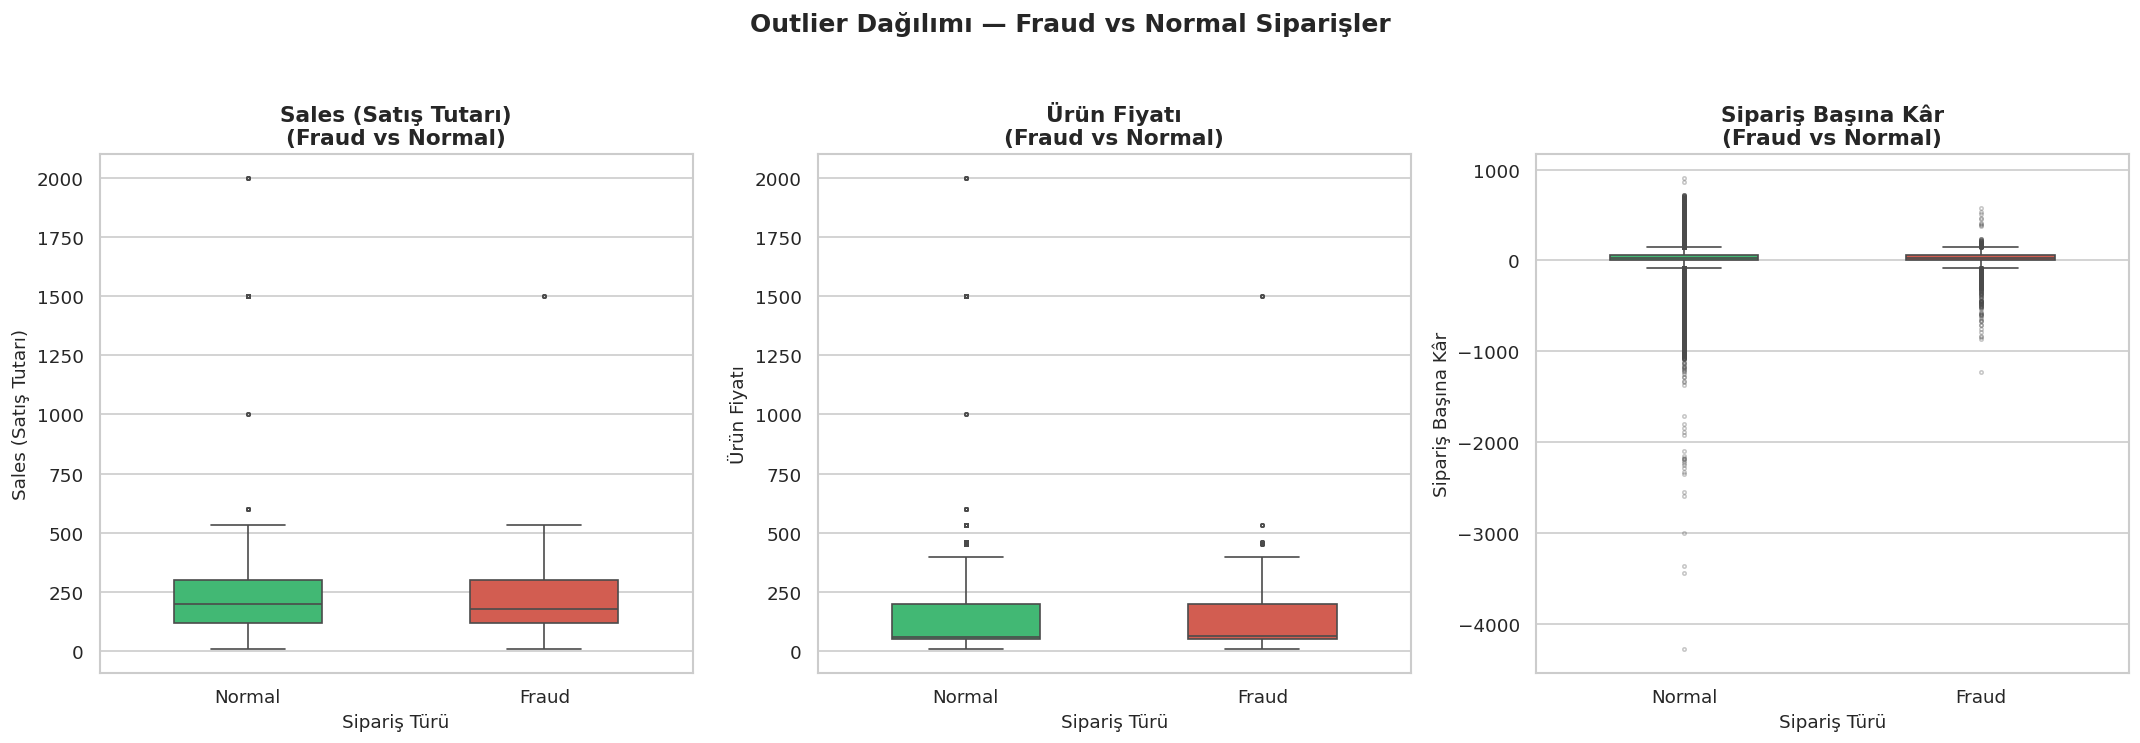

✅ Grafik 5 kaydedildi.


In [7]:
# ============================================================
# GRAFİK 5: Outlier Dağılımı — Fraud vs Normal Box Plot
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

box_cols = ['Sales', 'Order Item Product Price', 'Benefit per order']
box_titles = ['Sales (Satış Tutarı)', 'Ürün Fiyatı', 'Sipariş Başına Kâr']
palette = {'Normal': '#2ecc71', 'Fraud': '#e74c3c'}

for ax, col, title in zip(axes, box_cols, box_titles):
    sns.boxplot(data=df, x='fraud_label', y=col, ax=ax,
                hue='fraud_label', palette=palette, width=0.5,
                fliersize=2, flierprops=dict(marker='o', alpha=0.3),
                order=['Normal', 'Fraud'], legend=False)
    ax.set_xlabel('Sipariş Türü', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title}\n(Fraud vs Normal)', fontsize=13, fontweight='bold')

fig.suptitle('Outlier Dağılımı — Fraud vs Normal Siparişler',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik05_outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 5 kaydedildi.')

## 📌 [Grafik 6] Normalizasyon Öncesi ve Sonrası Değişken Dağılımları (Before/After Histogram)

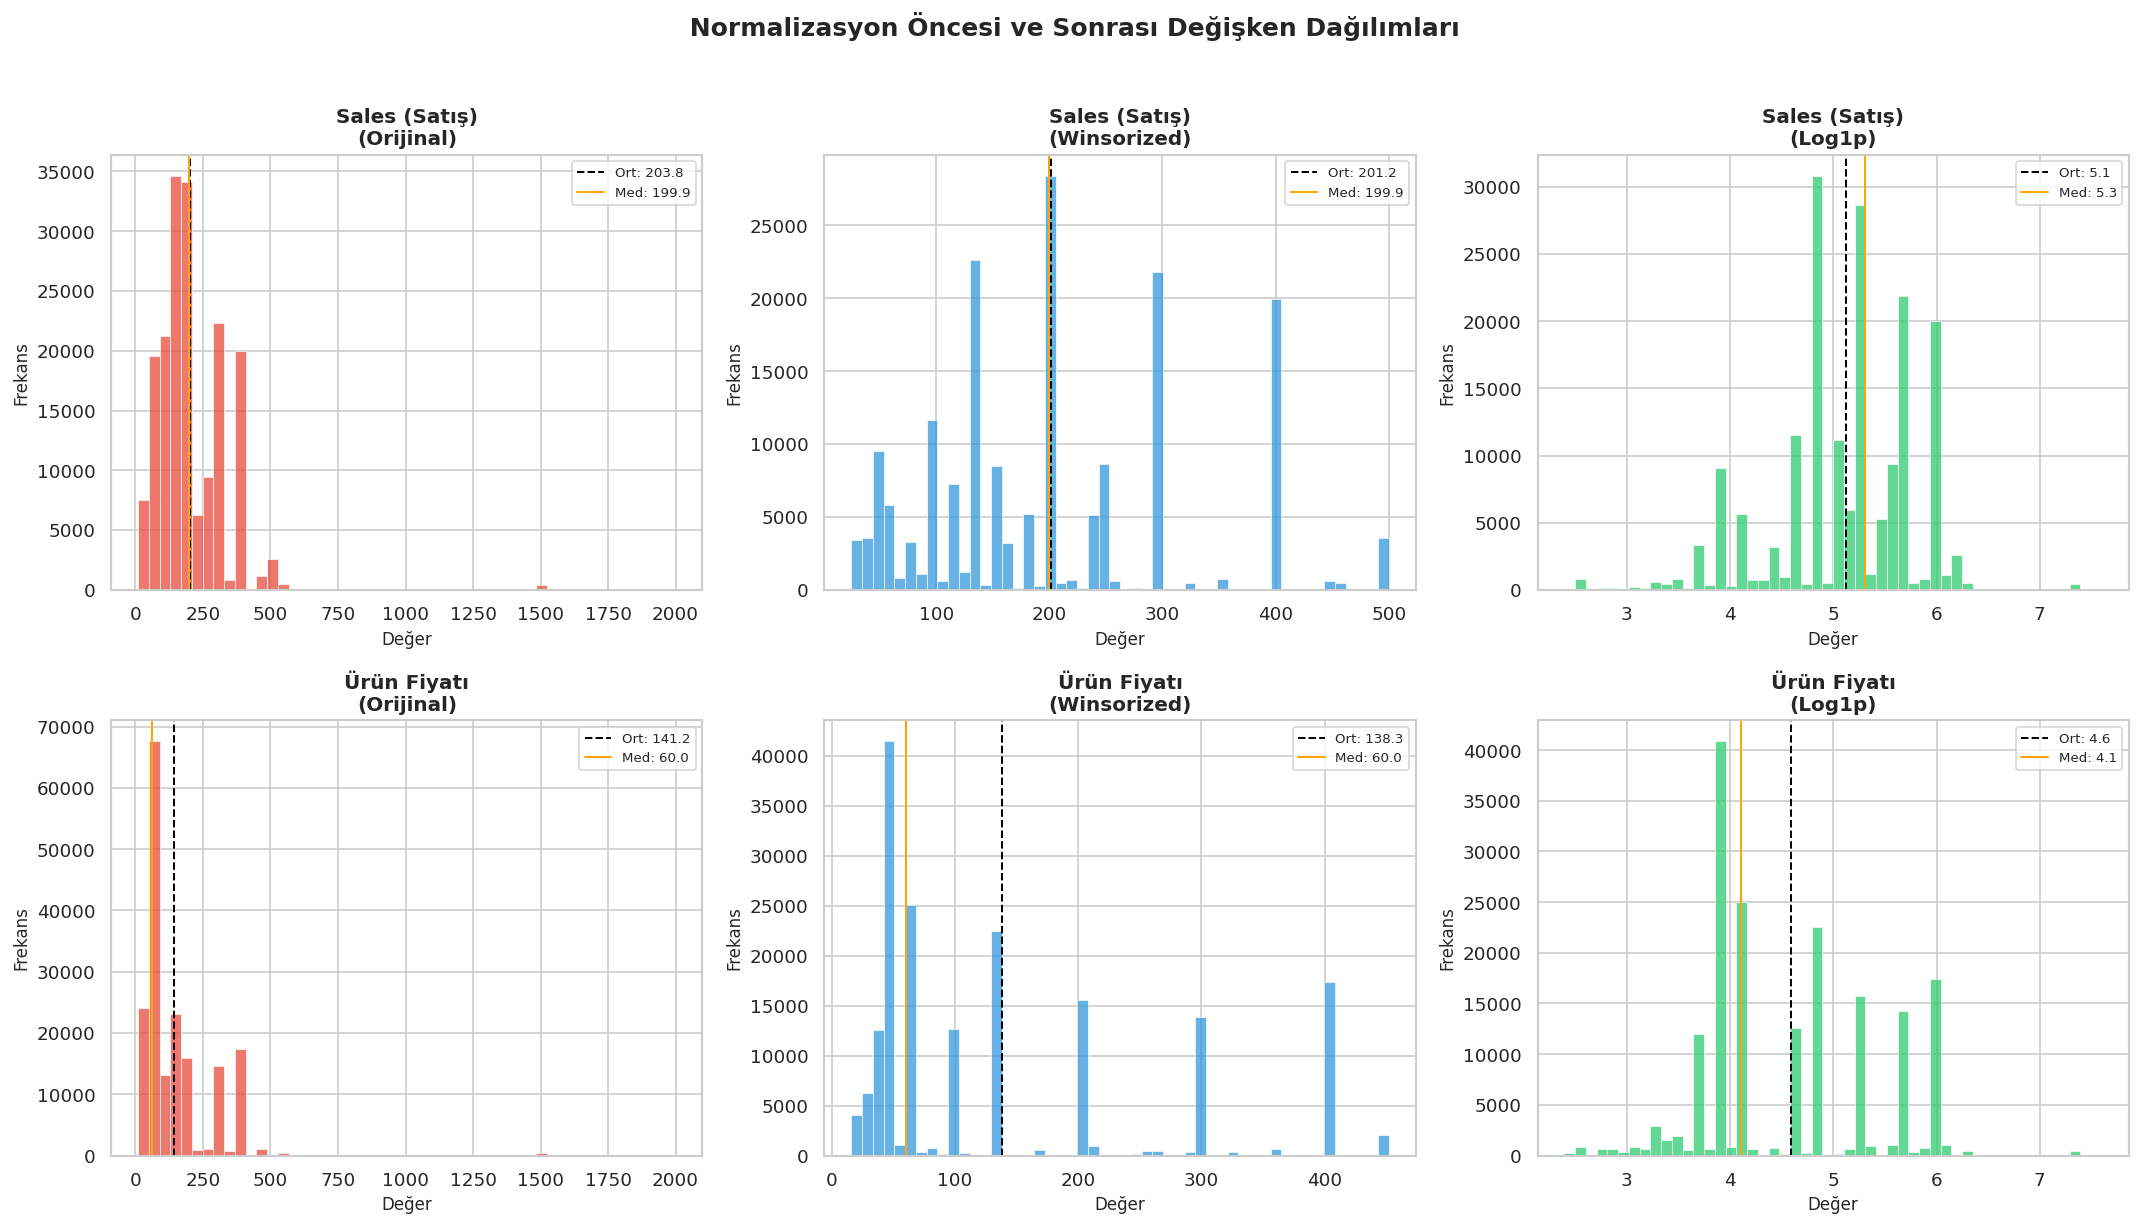

✅ Grafik 6 kaydedildi.


In [8]:
# ============================================================
# GRAFİK 6: Normalizasyon Öncesi ve Sonrası — Before/After Histogram
# ============================================================
norm_pairs = [
    ('Sales', 'Sales_winsor', 'Sales_log1p', 'Sales (Satış)'),
    ('Order Item Product Price', 'Order Item Product Price_winsor',
     'Order Item Product Price_log1p', 'Ürün Fiyatı'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = ['#e74c3c', '#3498db', '#2ecc71']
stages = ['Orijinal', 'Winsorized', 'Log1p']

for row_idx, (orig, winsor, log, label) in enumerate(norm_pairs):
    for col_idx, (col_name, stage, color) in enumerate(
        zip([orig, winsor, log], stages, colors)
    ):
        ax = axes[row_idx, col_idx]
        data = df[col_name].dropna()
        ax.hist(data, bins=50, color=color, alpha=0.75,
                edgecolor='white', linewidth=0.5)
        ax.set_title(f'{label}\n({stage})', fontsize=12, fontweight='bold')
        ax.set_xlabel('Değer', fontsize=10)
        ax.set_ylabel('Frekans', fontsize=10)
        ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2,
                   label=f'Ort: {data.mean():.1f}')
        ax.axvline(data.median(), color='orange', linestyle='-', linewidth=1.2,
                   label=f'Med: {data.median():.1f}')
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle(' Normalizasyon Öncesi ve Sonrası Değişken Dağılımları',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik06_normalizasyon_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 6 kaydedildi.')

## 📌 [Grafik 7] Karar Ağacı Görselleştirmesi (max_depth=5)

In [9]:
# ============================================================
# MODEL EĞİTİMİ — Grafik 7, 8, 9, 10 için ortak
# ============================================================
feature_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Benefit per order', 'Sales', 'Late_delivery_risk',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Quantity', 'Order Item Total',
    'Order Profit Per Order', 'shipping_delay',
    'negative_profit_flag'
]

X = df[feature_cols].fillna(0)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Decision Tree modeli
dt_model = DecisionTreeClassifier(
    max_depth=5, random_state=42, class_weight='balanced'
)
dt_model.fit(X_train, y_train)

print(f'Decision Tree — Eğitim Doğruluğu : {dt_model.score(X_train, y_train):.4f}')
print(f'Decision Tree — Test Doğruluğu   : {dt_model.score(X_test, y_test):.4f}')

Decision Tree — Eğitim Doğruluğu : 0.7081
Decision Tree — Test Doğruluğu   : 0.7090


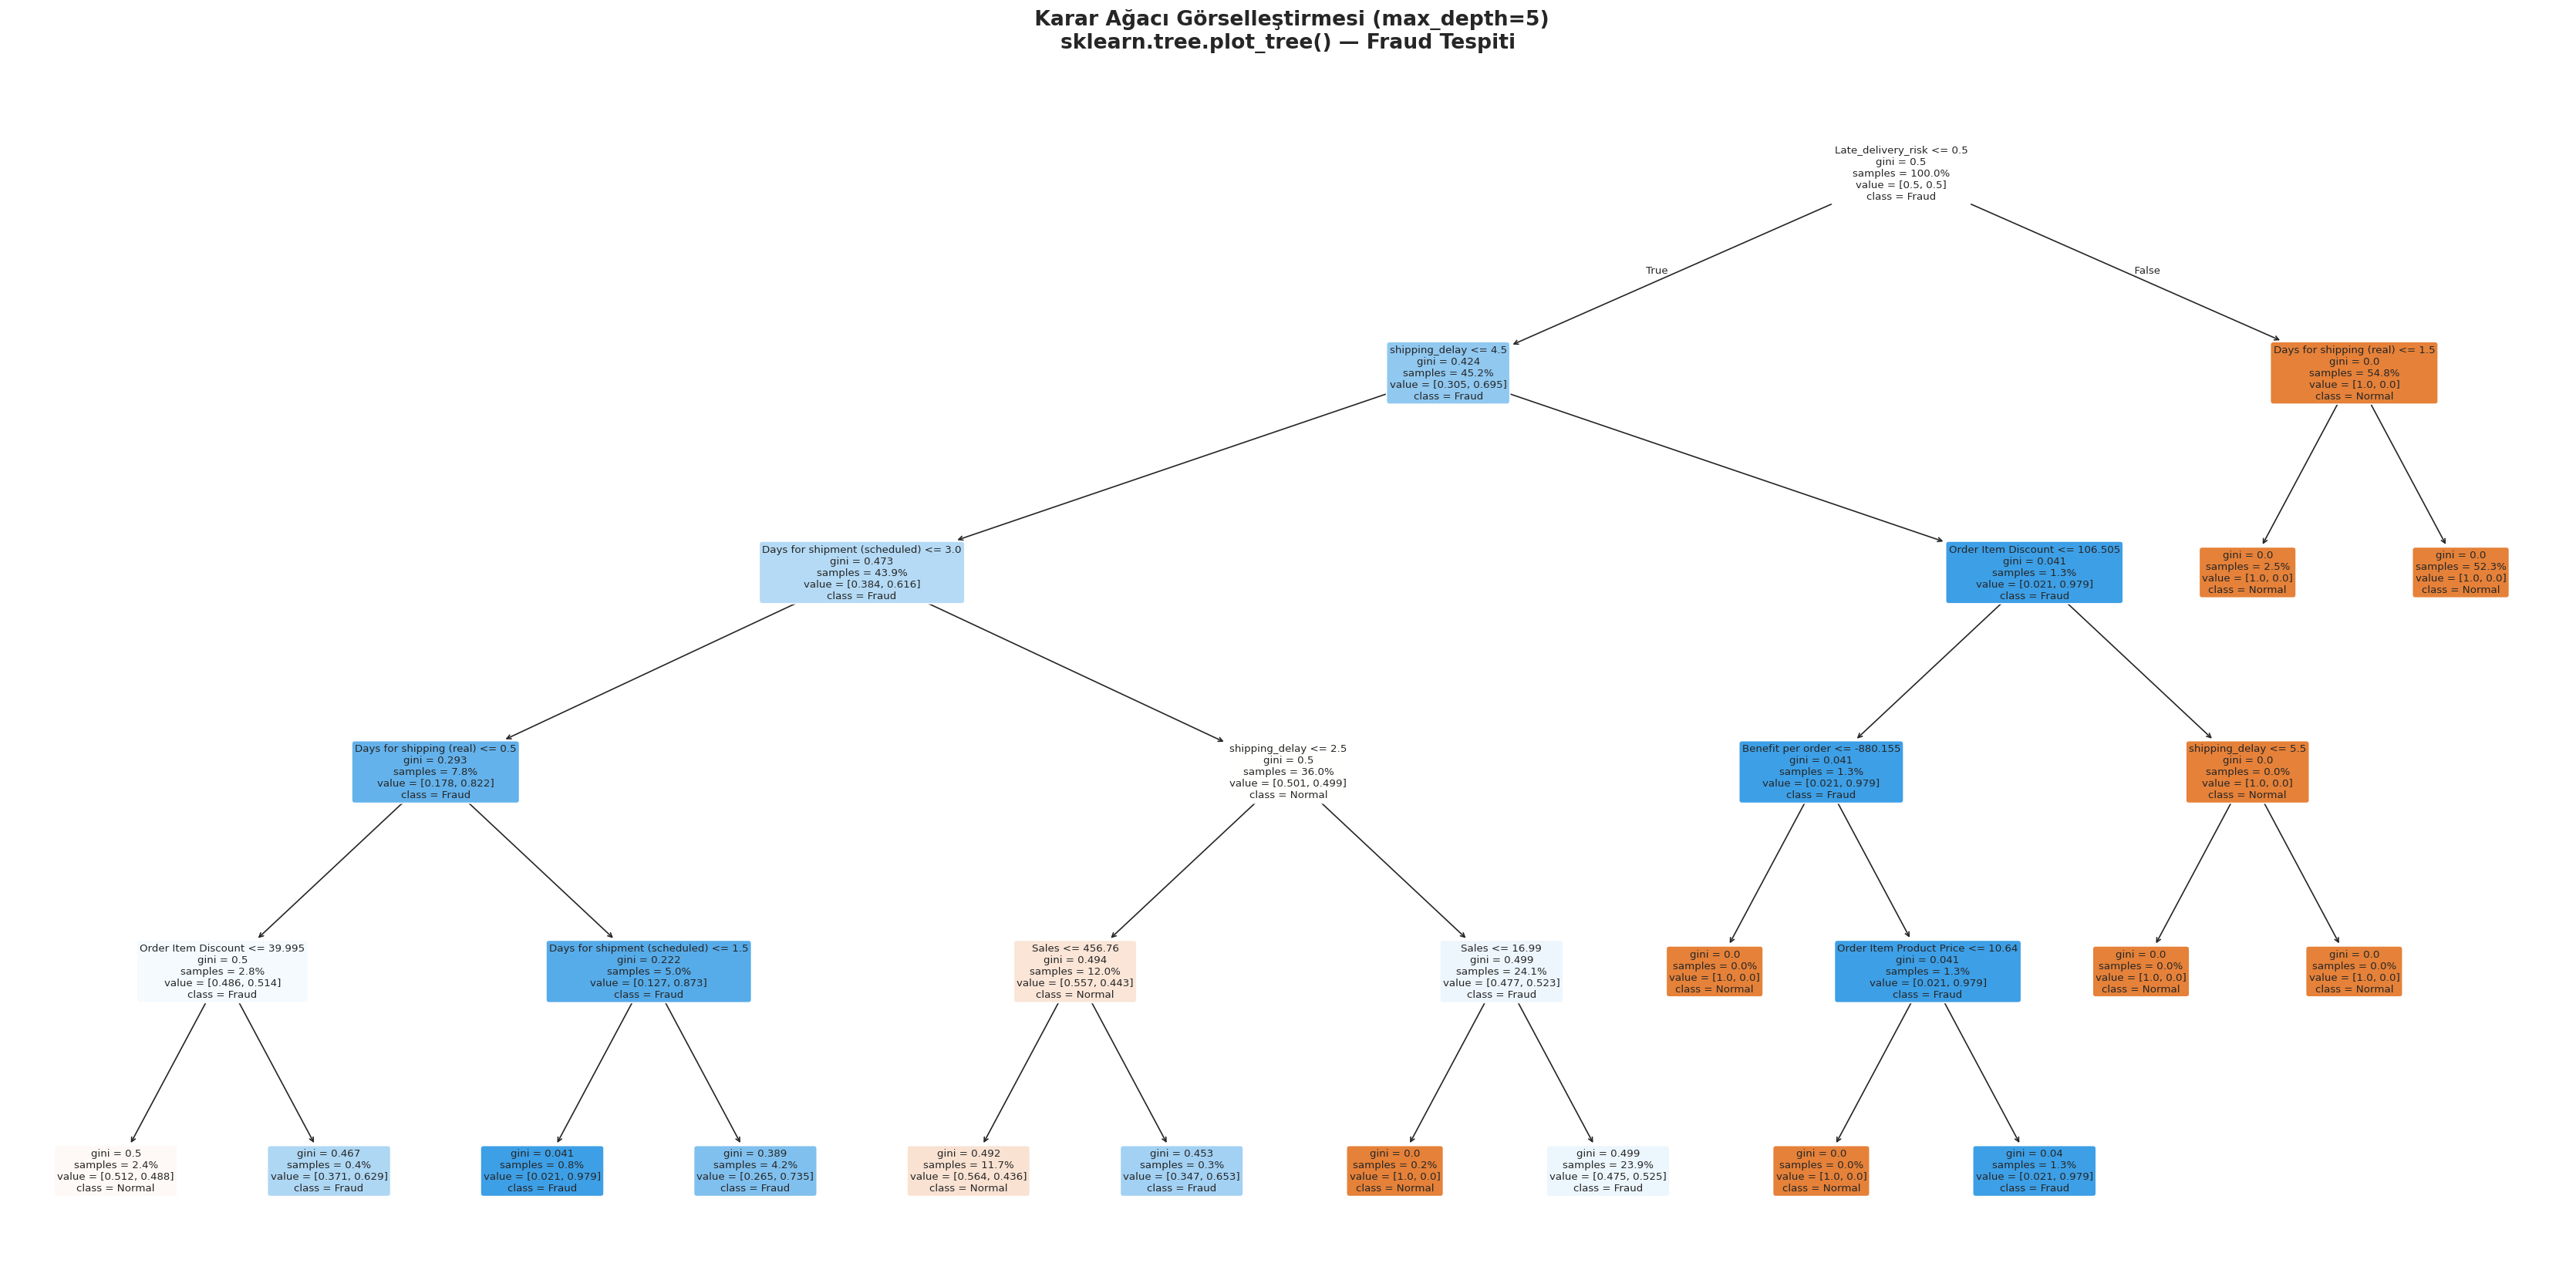

✅ Grafik 7 kaydedildi.


In [10]:
# ============================================================
# GRAFİK 7: Karar Ağacı Görselleştirmesi (max_depth=5)
# ============================================================
fig, ax = plt.subplots(figsize=(28, 14))

plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Normal', 'Fraud'],
    filled=True, rounded=True,
    ax=ax, fontsize=8,
    proportion=True, impurity=True
)

ax.set_title(' Karar Ağacı Görselleştirmesi (max_depth=5)\n'
             'sklearn.tree.plot_tree() — Fraud Tespiti',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../../analysis_images/grafik07_karar_agaci.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 7 kaydedildi.')

## 📌 [Grafik 8] Sınıflandırma Sonuçları — Confusion Matrix

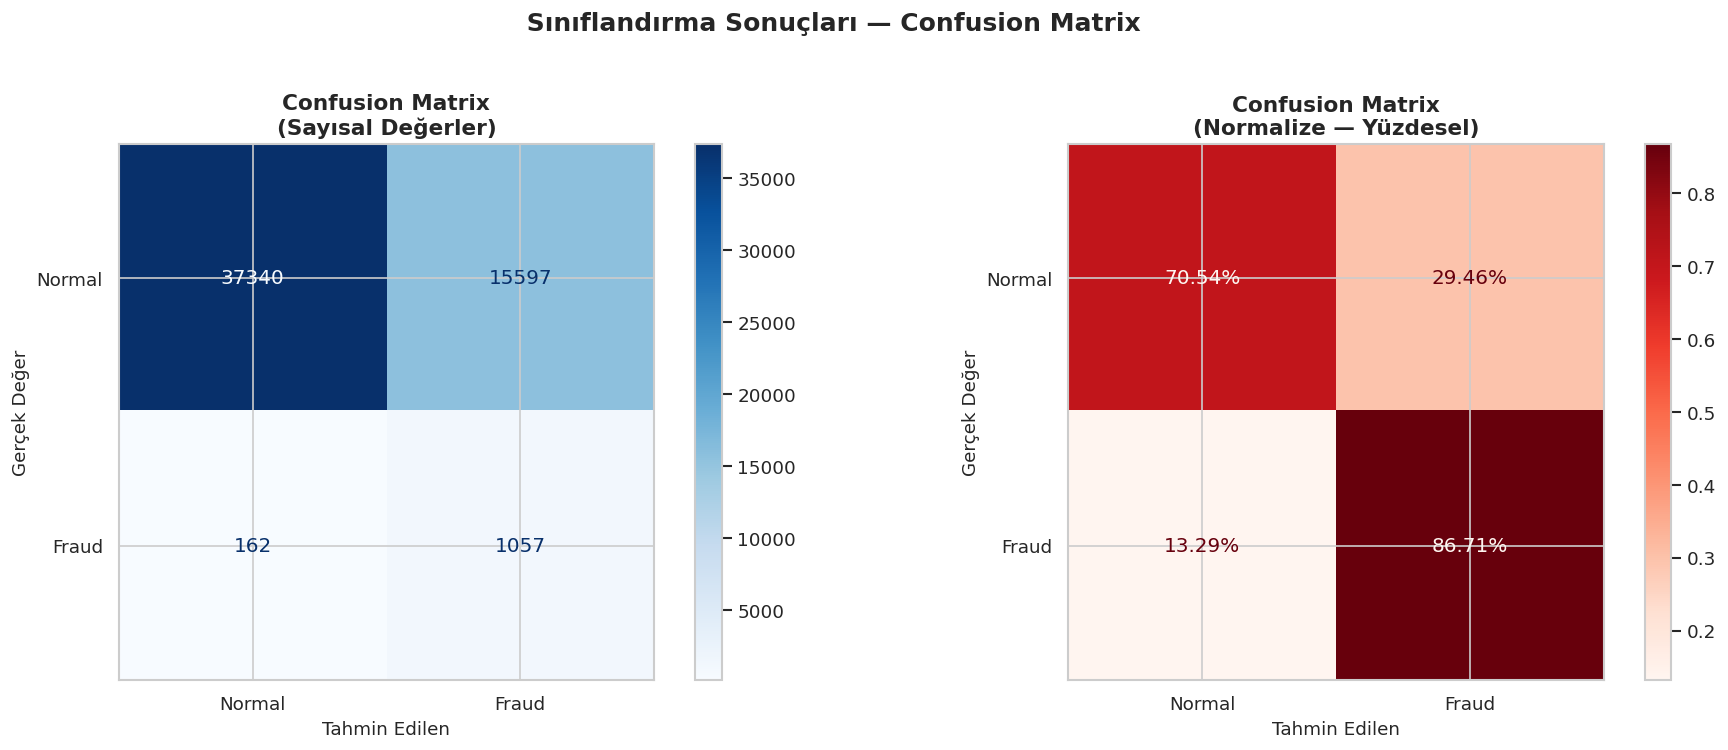


📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.71      0.83     52937
       Fraud       0.06      0.87      0.12      1219

    accuracy                           0.71     54156
   macro avg       0.53      0.79      0.47     54156
weighted avg       0.97      0.71      0.81     54156

✅ Grafik 8 kaydedildi.


In [11]:
# ============================================================
# GRAFİK 8: Confusion Matrix
# ============================================================
y_pred_dt = dt_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_dt)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Sayısal
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix\n(Sayısal Değerler)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen', fontsize=11)
axes[0].set_ylabel('Gerçek Değer', fontsize=11)

# Sağ: Normalize
cm_norm = confusion_matrix(y_test, y_pred_dt, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Normal', 'Fraud'])
disp2.plot(ax=axes[1], cmap='Reds', values_format='.2%')
axes[1].set_title('Confusion Matrix\n(Normalize — Yüzdesel)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tahmin Edilen', fontsize=11)
axes[1].set_ylabel('Gerçek Değer', fontsize=11)

fig.suptitle(' Sınıflandırma Sonuçları — Confusion Matrix',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Normal', 'Fraud']))
print('✅ Grafik 8 kaydedildi.')

---
# 🔵 BÖLÜM C — MODEL ÇIKTISI GRAFİKLERİ

## 📌 [Grafik 9] SHAP Summary Plot — Öznitelik Önem Sıralaması

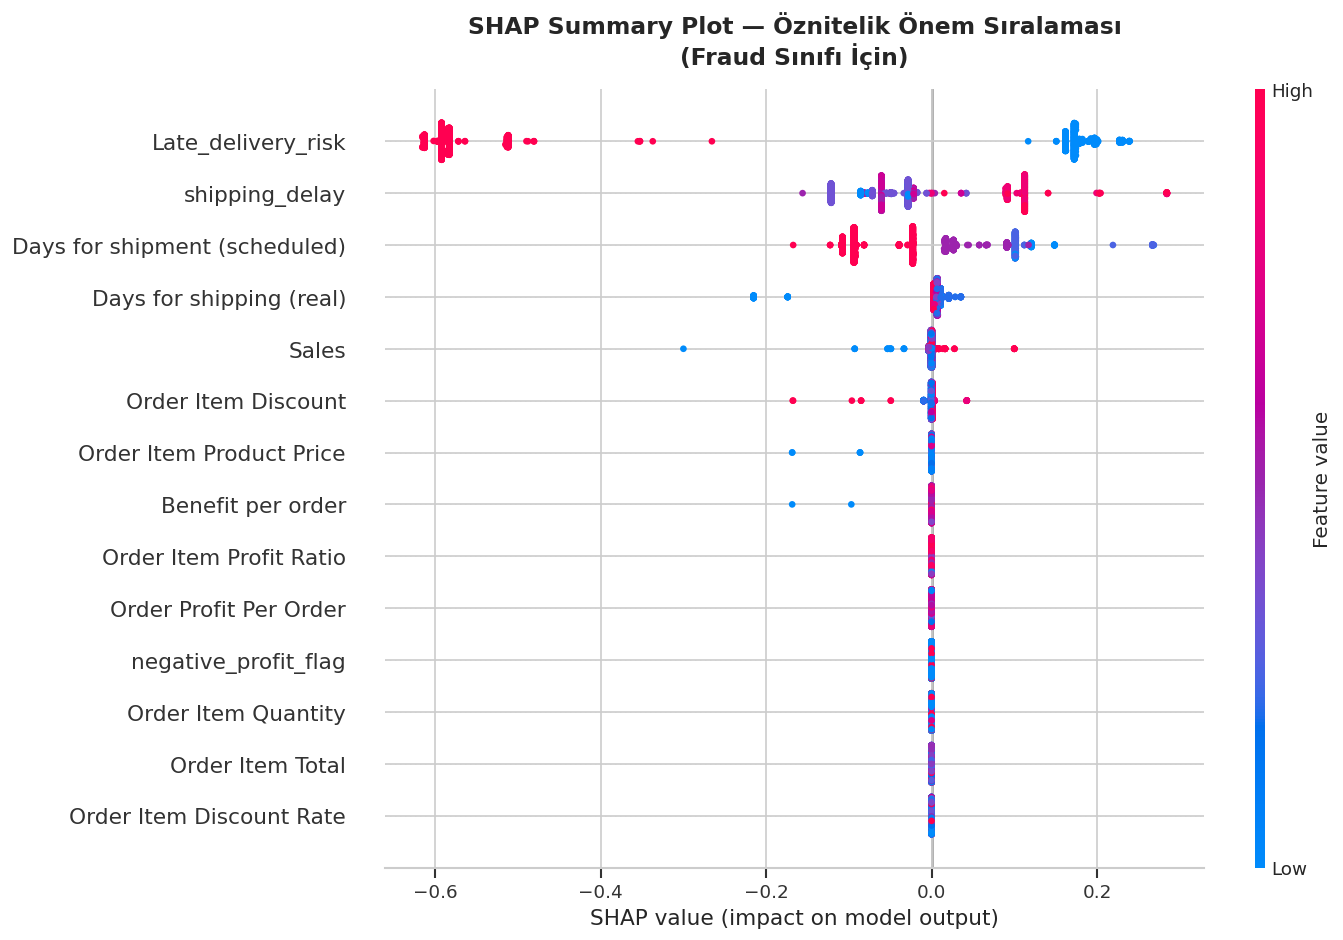

✅ Grafik 9 kaydedildi.


In [12]:
# ============================================================
# GRAFİK 9: SHAP Summary Plot
# ============================================================
X_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(dt_model)
shap_values = explainer.shap_values(X_sample)

# Eğer shap_values 3D ise (n_samples, n_features, n_classes) → Fraud sınıfını al
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure(figsize=(12, 8))
shap.summary_plot(sv, X_sample,
                  feature_names=feature_cols,
                  show=False, plot_size=(12, 8))
plt.title('SHAP Summary Plot — Öznitelik Önem Sıralaması\n'
          '(Fraud Sınıfı İçin)',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik09_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 9 kaydedildi.')

## 📌 [Grafik 10] ROC-AUC Eğrisi — Decision Tree vs XGBoost

XGBoost — Eğitim Doğruluğu : 0.8114
XGBoost — Test Doğruluğu   : 0.8038


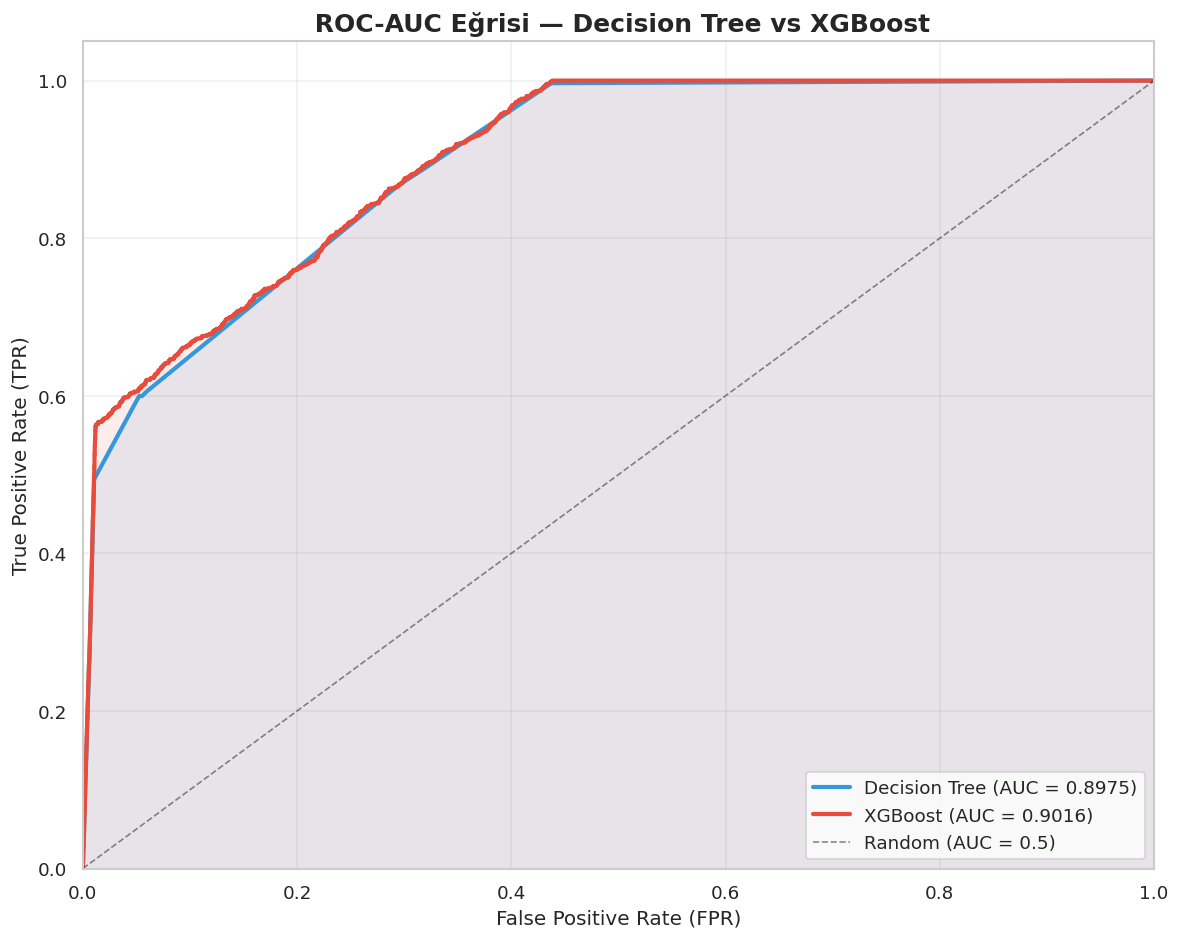

✅ Grafik 10 kaydedildi.


In [13]:
# ============================================================
# GRAFİK 10: ROC-AUC Eğrisi — Decision Tree vs XGBoost
# ============================================================
xgb_model = xgb.XGBClassifier(
    max_depth=5, n_estimators=100,
    learning_rate=0.1, random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train, verbose=False)

print(f'XGBoost — Eğitim Doğruluğu : {xgb_model.score(X_train, y_train):.4f}')
print(f'XGBoost — Test Doğruluğu   : {xgb_model.score(X_test, y_test):.4f}')

# ROC eğrileri
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_dt = auc(fpr_dt, tpr_dt)
auc_xgb = auc(fpr_xgb, tpr_xgb)

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_dt, tpr_dt, color='#3498db', linewidth=2.5,
        label=f'Decision Tree (AUC = {auc_dt:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2.5,
        label=f'XGBoost (AUC = {auc_xgb:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.1, color='#e74c3c')
ax.fill_between(fpr_dt, tpr_dt, alpha=0.1, color='#3498db')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title(' ROC-AUC Eğrisi — Decision Tree vs XGBoost',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../analysis_images/grafik10_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 10 kaydedildi.')

## 📌 [Grafik 11] Prophet 12 Aylık Talep Tahmini — Trend ve Mevsimsellik Bileşenleri

01:49:12 - cmdstanpy - INFO - Chain [1] start processing


01:49:12 - cmdstanpy - INFO - Chain [1] done processing


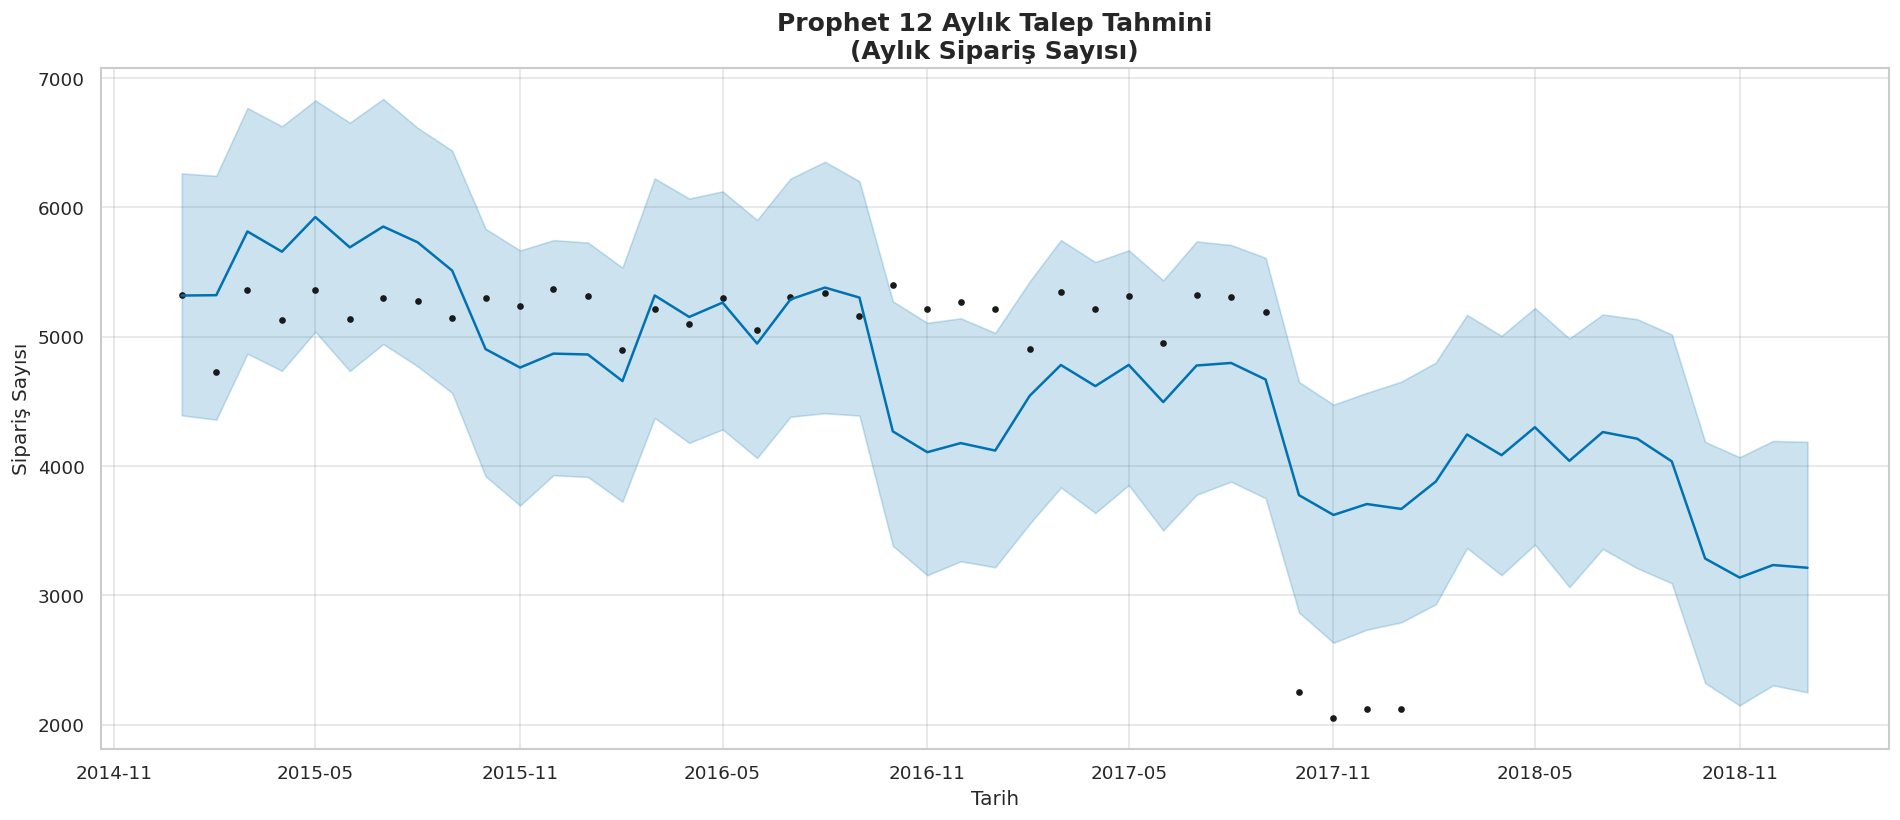

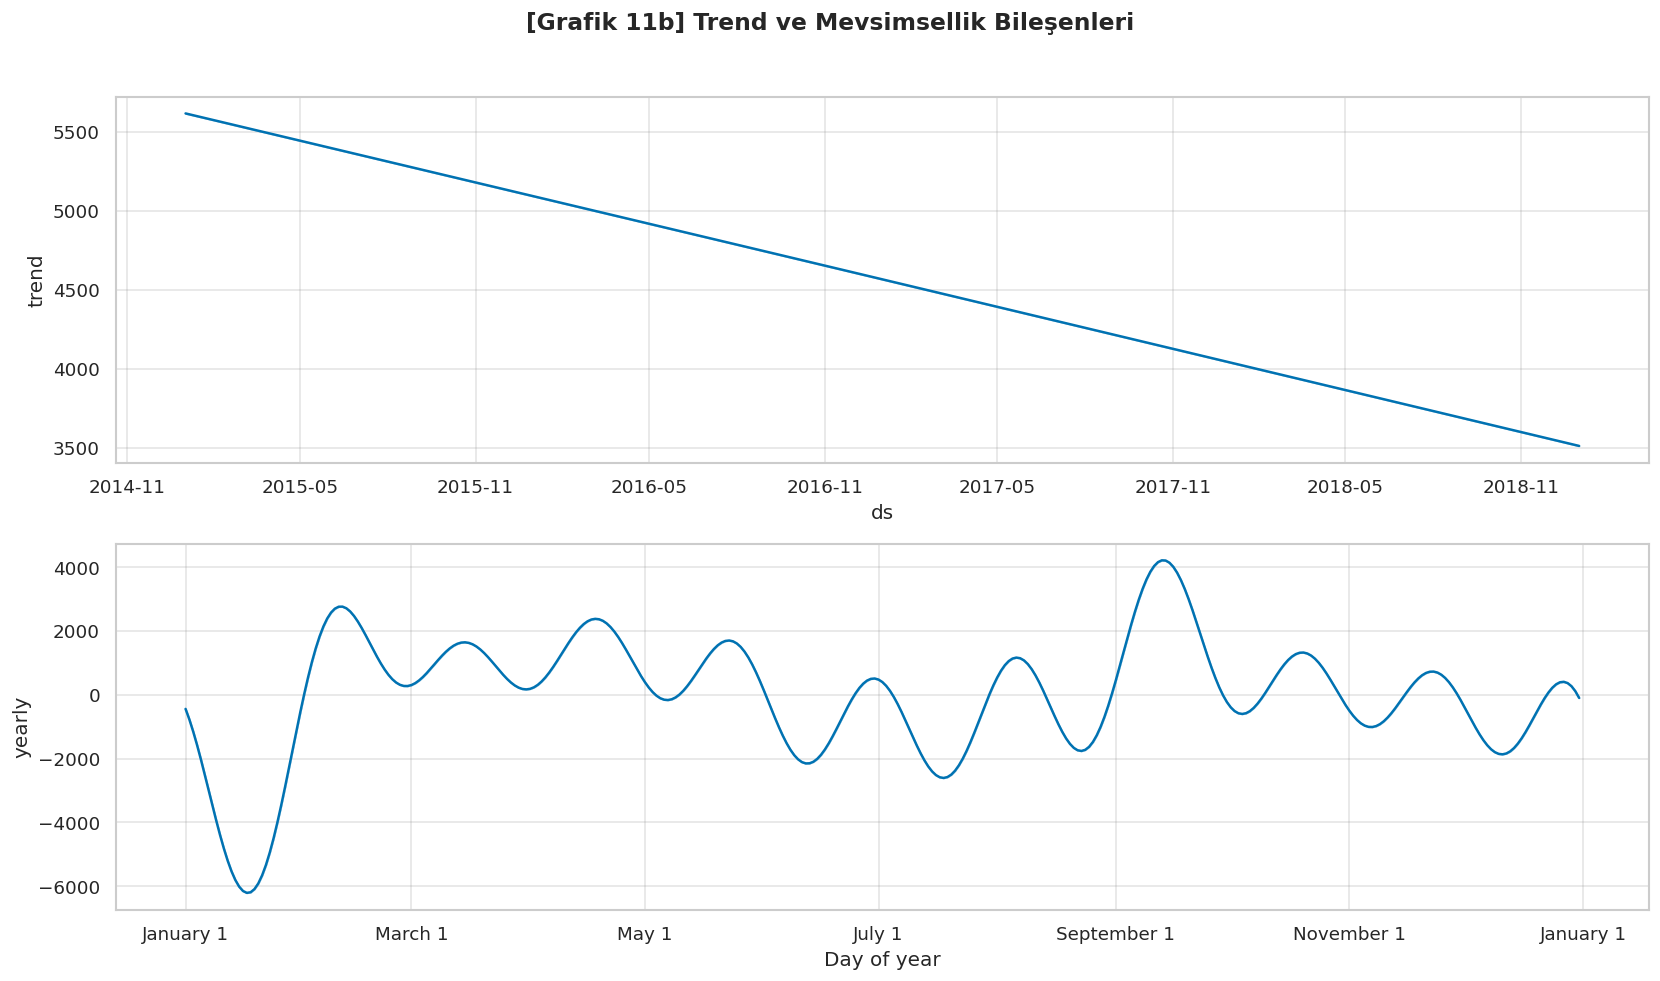

✅ Grafik 11 kaydedildi.


In [14]:
# ============================================================
# GRAFİK 11: Prophet 12 Aylık Talep Tahmini
# ============================================================
df_prophet = (df.groupby(df['order_date'].dt.to_period('M'))
              .size().reset_index(name='y'))
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = df_prophet['ds'].dt.to_timestamp()

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model_prophet.fit(df_prophet)

future = model_prophet.make_future_dataframe(periods=12, freq='MS')
forecast = model_prophet.predict(future)

# Ana grafik
fig1 = model_prophet.plot(forecast, figsize=(16, 7))
plt.title('Prophet 12 Aylık Talep Tahmini\n(Aylık Sipariş Sayısı)',
          fontsize=15, fontweight='bold')
plt.xlabel('Tarih', fontsize=12)
plt.ylabel('Sipariş Sayısı', fontsize=12)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik11_prophet_tahmin.png', dpi=150, bbox_inches='tight')
plt.show()

# Bileşenler grafiği (Trend + Mevsimsellik)
fig2 = model_prophet.plot_components(forecast, figsize=(14, 8))
plt.suptitle('[Grafik 11b] Trend ve Mevsimsellik Bileşenleri',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik11b_prophet_bilesenler.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 11 kaydedildi.')

## 📌 [Grafik 12] Isolation Forest — Anomali Skoru Dağılımı

Tespit edilen anomali sayısı: 3,611 / 180,519 (2.00%)


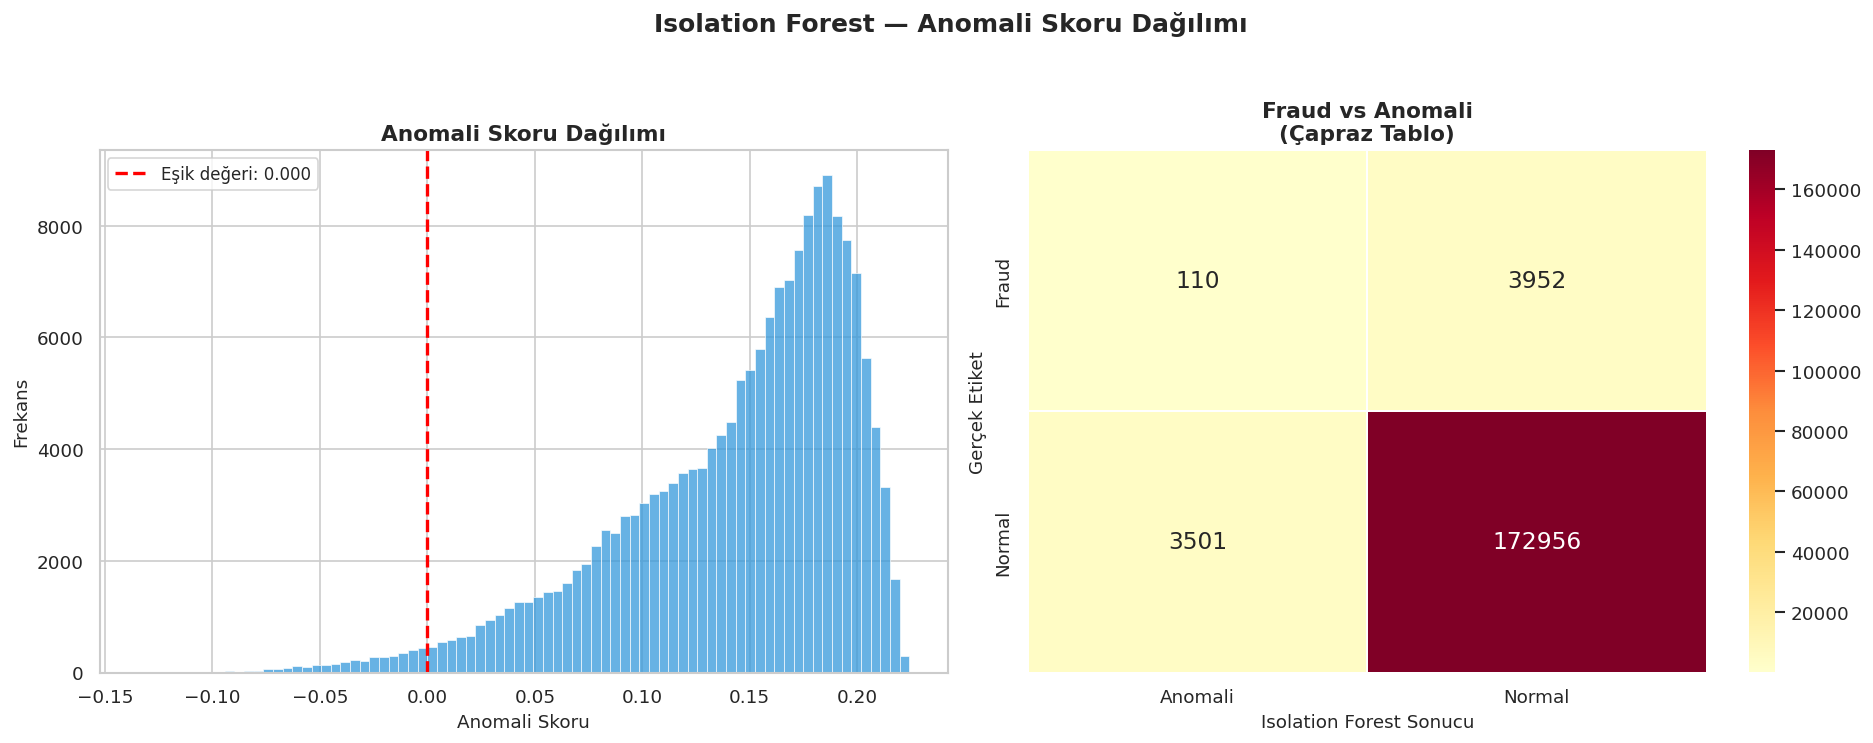

✅ Grafik 12 kaydedildi.


In [15]:
# ============================================================
# GRAFİK 12: Isolation Forest — Anomali Skoru Dağılımı
# ============================================================
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X)
anomaly_scores = iso_forest.decision_function(X)
anomaly_labels = iso_forest.predict(X)

n_anomalies = (anomaly_labels == -1).sum()
print(f'Tespit edilen anomali sayısı: {n_anomalies:,} / {len(X):,} '
      f'({n_anomalies/len(X)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Anomali Skoru Dağılımı
axes[0].hist(anomaly_scores, bins=80, color='#3498db', alpha=0.75,
             edgecolor='white', linewidth=0.5)
threshold = np.percentile(anomaly_scores, 2)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Eşik değeri: {threshold:.3f}')
axes[0].set_title('Anomali Skoru Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Anomali Skoru', fontsize=11)
axes[0].set_ylabel('Frekans', fontsize=11)
axes[0].legend(fontsize=10)

# Sağ: Fraud vs Anomali karşılaştırması
df_anomaly = pd.DataFrame({
    'Gerçek': ['Fraud' if f == 1 else 'Normal' for f in df['is_fraud'].values],
    'Tespit': ['Anomali' if a == -1 else 'Normal' for a in anomaly_labels]
})
ct = pd.crosstab(df_anomaly['Gerçek'], df_anomaly['Tespit'])

sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[1].set_title('Fraud vs Anomali\n(Çapraz Tablo)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Isolation Forest Sonucu', fontsize=11)
axes[1].set_ylabel('Gerçek Etiket', fontsize=11)

fig.suptitle('Isolation Forest — Anomali Skoru Dağılımı',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../../analysis_images/grafik12_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik 12 kaydedildi.')

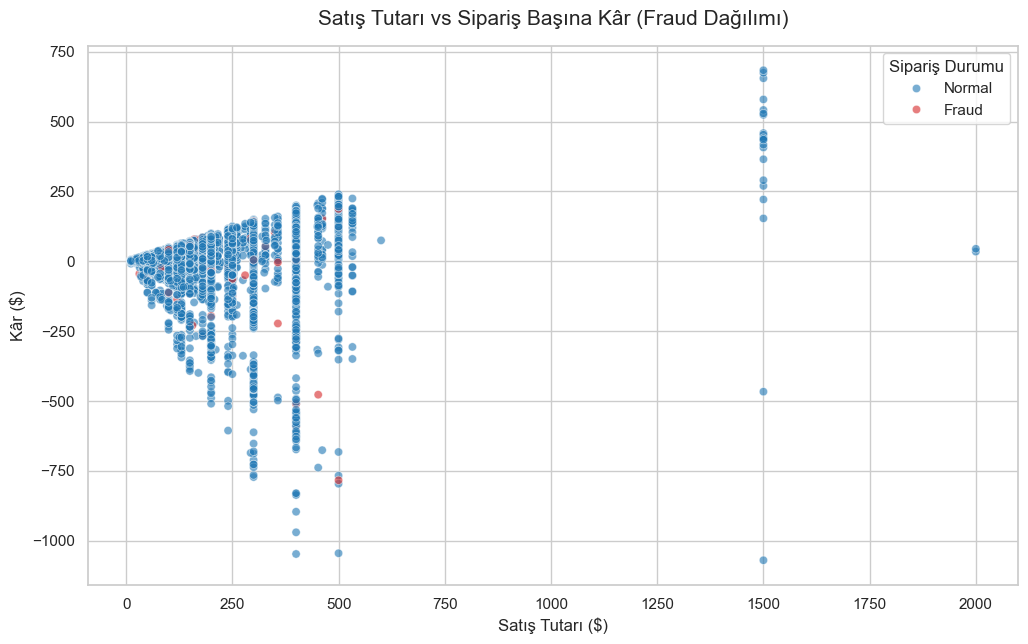

✅ Grafik 13 başarıyla oluşturuldu: ../../analysis_images\grafik13_scatter_sales_profit.png


In [6]:
# ============================================================
# GRAFİK 13: Satış ve Kâr İlişkisi (Scatter Plot) - Self Contained
# ============================================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi tekrar yükleyelim (Eğer yukarıdaki hücreleri çalıştırmadıysanız)
try:
    if 'df' not in locals():
        df = pd.read_csv('../../data/temiz_veri_final_latest.csv')
        df['fraud_label'] = df['Order Status'].apply(
            lambda x: 'Fraud' if x == 'SUSPECTED_FRAUD' else 'Normal'
        )
    
    # 2. Grafik Ayarları
    plt.figure(figsize=(12, 7))
    sns.set_theme(style='whitegrid')

    # Performans için örneklem
    plot_df = df.sample(n=min(10000, len(df)), random_state=42)

    # 3. Çizim
    sns.scatterplot(
        data=plot_df,
        x='Sales',
        y='Benefit per order',
        hue='fraud_label',
        alpha=0.6,
        edgecolor='w',
        palette={'Normal': '#1f77b4', 'Fraud': '#d62728'}
    )

    plt.title('Satış Tutarı vs Sipariş Başına Kâr (Fraud Dağılımı)', fontsize=15, pad=15)
    plt.xlabel('Satış Tutarı ($)', fontsize=12)
    plt.ylabel('Kâr ($)', fontsize=12)
    plt.legend(title='Sipariş Durumu')

    # 4. Kaydet
    save_path = os.path.join('../../analysis_images', 'grafik13_scatter_sales_profit.png')
    os.makedirs('../../analysis_images', exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

    print(f'✅ Grafik 13 başarıyla oluşturuldu: {save_path}')

except Exception as e:
    print(f"❌ Bir hata oluştu: {e}")
    print("İpucu: Veri dosyasının doğru konumda olduğundan emin olun.")


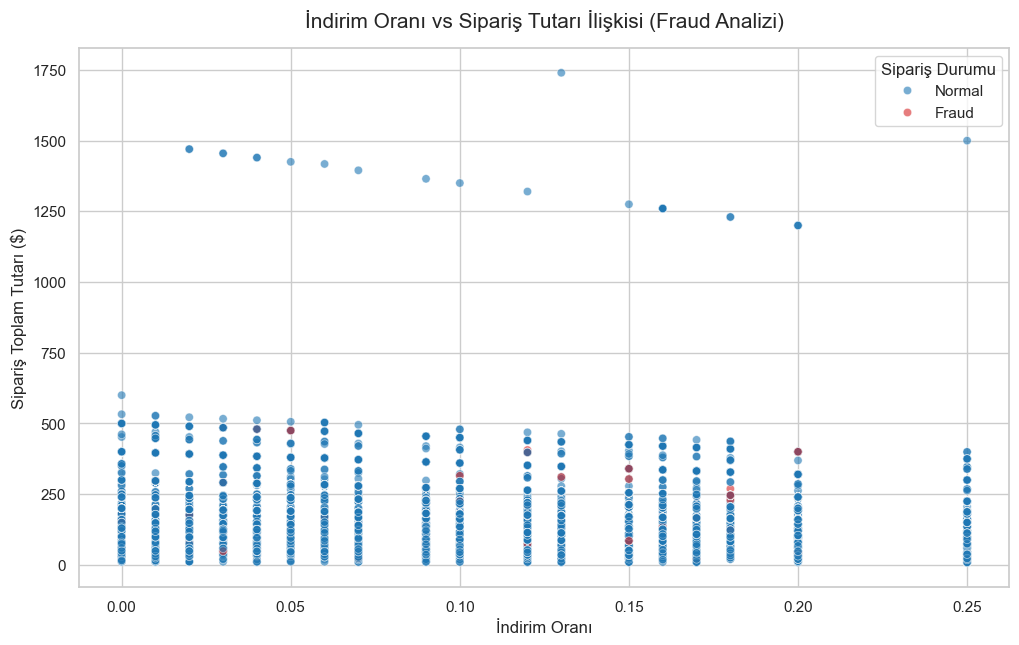

✅ Grafik 13 (İndirim/Sipariş) başarıyla oluşturuldu: ../../analysis_images\grafik13_indirim_siparis_iliski.png


In [7]:
# ============================================================
# GRAFİK 13: İndirim Oranı vs Sipariş Tutarı (Scatter Plot)
# ============================================================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi kontrol et/yükle
try:
    if 'df' not in locals():
        df = pd.read_csv('../../data/temiz_veri_final_latest.csv')
        df['fraud_label'] = df['Order Status'].apply(
            lambda x: 'Fraud' if x == 'SUSPECTED_FRAUD' else 'Normal'
        )
    
    # 2. Grafik Ayarları
    plt.figure(figsize=(12, 7))
    sns.set_theme(style='whitegrid')

    # Performans için örneklem
    plot_df = df.sample(n=min(10000, len(df)), random_state=42)

    # 3. Çizim
    sns.scatterplot(
        data=plot_df,
        x='Order Item Discount Rate', 
        y='Order Item Total',
        hue='fraud_label',
        alpha=0.6,
        edgecolor='w',
        palette={'Normal': '#1f77b4', 'Fraud': '#d62728'}
    )

    plt.title('İndirim Oranı vs Sipariş Tutarı İlişkisi (Fraud Analizi)', fontsize=15, pad=15)
    plt.xlabel('İndirim Oranı', fontsize=12)
    plt.ylabel('Sipariş Toplam Tutarı ($)', fontsize=12)
    plt.legend(title='Sipariş Durumu')

    # 4. Kaydet
    save_path = os.path.join('../../analysis_images', 'grafik13_indirim_siparis_iliski.png')
    os.makedirs('../../analysis_images', exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

    print(f'✅ Grafik 13 (İndirim/Sipariş) başarıyla oluşturuldu: {save_path}')

except Exception as e:
    print(f"❌ Bir hata oluştu: {e}")


---
## ✅ Tüm Grafikler Tamamlandı!

Kaydedilen dosyalar (`analysis_images/` klasörü):

| # | Dosya Adı | Grafik |
|---|----------|--------|
| 1 | `grafik01_korelasyon_heatmap.png` | Korelasyon Isı Haritası |
| 2 | `grafik02_aylik_satis_trendi.png` | Aylık Satış Trendi |
| 3 | `grafik03_haversine_histogram.png` | Haversine Mesafesi |
| 4 | `grafik04_zscore_boxplot.png` | Z-Skoru Box Plot |
| 5 | `grafik05_outlier_boxplot.png` | Outlier Box Plot |
| 6 | `grafik06_normalizasyon_histogram.png` | Normalizasyon Histogramları |
| 7 | `grafik07_karar_agaci.png` | Karar Ağacı |
| 8 | `grafik08_confusion_matrix.png` | Confusion Matrix |
| 9 | `grafik09_shap_summary.png` | SHAP Summary |
| 10 | `grafik10_roc_auc.png` | ROC-AUC Eğrisi |
| 11 | `grafik11_prophet_tahmin.png` | Prophet Tahmin |
| 11b | `grafik11b_prophet_bilesenler.png` | Prophet Bileşenleri |
| 12 | `grafik12_isolation_forest.png` | Isolation Forest |

📊 Zaman Serisi Pivot Tablosu (İlk 10 Satır):


,Sales,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
order_date,,,,,,
2015-01-31,1.051590e+06,NaN,NaN,NaN,NaN,NaN
2015-02-28,9.270099e+05,1.051590e+06,NaN,NaN,NaN,NaN
2015-03-31,1.051254e+06,9.270099e+05,1.051590e+06,NaN,1.009951e+06,71829.491163
2015-04-30,1.014463e+06,1.051254e+06,9.270099e+05,1.051590e+06,9.975756e+05,63820.253003
2015-05-31,1.050478e+06,1.014463e+06,1.051254e+06,9.270099e+05,1.038732e+06,21020.732195
2015-06-30,1.024006e+06,1.050478e+06,1.014463e+06,1.051254e+06,1.029649e+06,18658.955041
2015-07-31,1.038081e+06,1.024006e+06,1.050478e+06,1.014463e+06,1.037522e+06,13244.993396
2015-08-31,1.029495e+06,1.038081e+06,1.024006e+06,1.050478e+06,1.030527e+06,7094.105875
2015-09-30,1.018339e+06,1.029495e+06,1.038081e+06,1.024006e+06,1.028638e+06,9899.126195


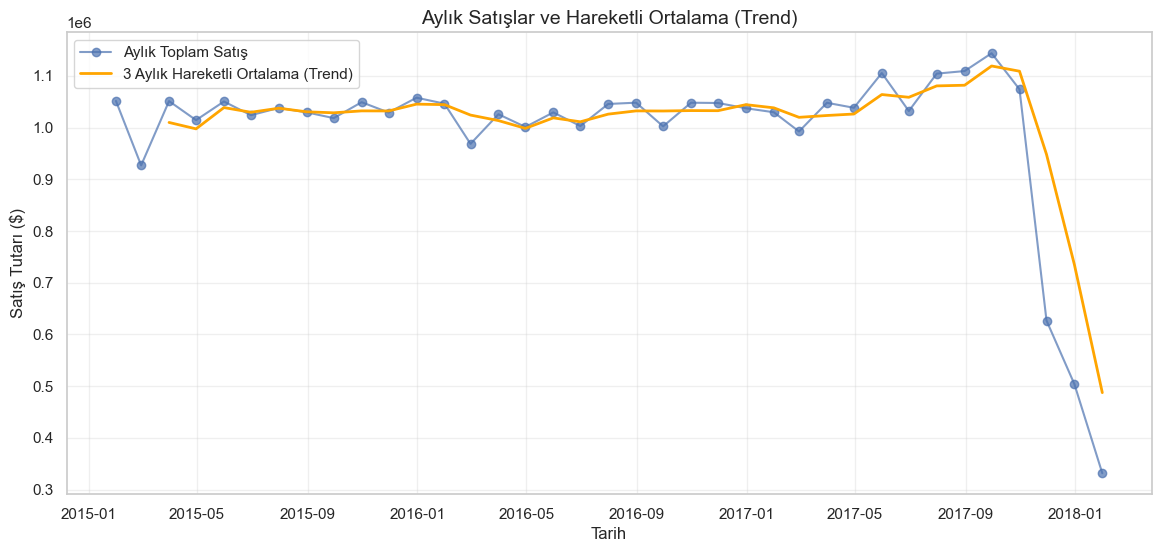

✅ Zaman serisi özellikleri (Lag & Trend) başarıyla oluşturuldu.


In [9]:
# ============================================================
# ZAMAN SERİSİ (LSTM) İÇİN ÖZNİTELİK MÜHENDİSİĞİ
# Aylık Satış, Lag ve Trend Özellikleri
# ============================================================

# 1. Tarih sütununu indeks yaparak aylık bazda satışları toplayalım
# (Eğer df yüklü değilse üstteki hücreleri çalıştırın)
df['order_date'] = pd.to_datetime(df['order_date'])
# 'M' yerine 'ME' (Month End) kullanarak uyarıyı gideriyoruz
monthly_sales = df.resample('ME', on='order_date')['Sales'].sum().to_frame()


# 2. Lag (Gecikme) Özellikleri - shift()
# Bir önceki ayın (lag_1), iki önceki ayın (lag_2) satışlarını ekleyelim
monthly_sales['lag_1'] = monthly_sales['Sales'].shift(1)
monthly_sales['lag_2'] = monthly_sales['Sales'].shift(2)
monthly_sales['lag_3'] = monthly_sales['Sales'].shift(3)

# 3. Trend (Sürüklenen/Hareketli) Özellikler - rolling()
# Son 3 aylık ortalama (trend) ve standart sapmayı hesaplayalım
# min_periods=1, eksik verileri (başlangıçtaki) doldurmak için kullanılır
monthly_sales['rolling_mean_3'] = monthly_sales['Sales'].rolling(window=3).mean()
monthly_sales['rolling_std_3'] = monthly_sales['Sales'].rolling(window=3).std()

# 4. Eksik verileri temizleme (Lag ve rolling sebebiyle ilk satırlar NaN olur)
# LSTM eğitimine girmeden önce NaN değerleri temizlemek veya doldurmak gerekir.
# monthly_sales.dropna(inplace=True)

# Sonuçları inceleyelim
print("📊 Zaman Serisi Pivot Tablosu (İlk 10 Satır):")
display(monthly_sales.head(10))

# Görselleştirme: Satış ve 3 Aylık Trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales['Sales'], label='Aylık Toplam Satış', marker='o', alpha=0.7)
plt.plot(monthly_sales.index, monthly_sales['rolling_mean_3'], label='3 Aylık Hareketli Ortalama (Trend)', color='orange', linewidth=2)
plt.title('Aylık Satışlar ve Hareketli Ortalama (Trend)', fontsize=14)
plt.xlabel('Tarih')
plt.ylabel('Satış Tutarı ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Zaman serisi özellikleri (Lag & Trend) başarıyla oluşturuldu.")
